In [ ]:

from google.colab import drive

# Mount the Google Drive to access files
drive.mount('/content/drive')

# Assuming the file is stored in a folder named "oews" in your Google Drive
file_path = '/content/drive/My Drive/Others/T10YIE.csv'

Mounted at /content/drive


In [ ]:
import pandas as pd
data = pd.read_csv(file_path)

# Display the first few rows of the dataset
data.head()


,DATE,T10YIE
0,2019-11-22,1.62
1,2019-11-25,1.62
2,2019-11-26,1.62
3,2019-11-27,1.63
4,2019-11-28,.


In [ ]:
# Basic information about the dataset
data.info()

# Check for missing values
print("\nMissing Values:\n", data.isnull().sum())

# Display the first few rows again for reference
data.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1306 entries, 0 to 1305
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   DATE    1306 non-null   object
 1   T10YIE  1306 non-null   object
dtypes: object(2)
memory usage: 20.5+ KB

Missing Values:
 DATE      0
T10YIE    0
dtype: int64


,DATE,T10YIE
0,2019-11-22,1.62
1,2019-11-25,1.62
2,2019-11-26,1.62
3,2019-11-27,1.63
4,2019-11-28,.


In [ ]:
import numpy as np

# Convert DATE to datetime format
data['DATE'] = pd.to_datetime(data['DATE'])

# Replace invalid entries in T10YIE with NaN
data['T10YIE'] = pd.to_numeric(data['T10YIE'], errors='coerce')

# Check for missing values again
print("Missing values after cleaning:")
print(data.isnull().sum())

# Optionally drop rows with missing values
data = data.dropna()

# Set DATE as the index for time series analysis
data.set_index('DATE', inplace=True)

# Display the first few rows of the cleaned dataset
data.head()


Missing values after cleaning:
DATE       0
T10YIE    54
dtype: int64


,T10YIE
DATE,
2019-11-22,1.62
2019-11-25,1.62
2019-11-26,1.62
2019-11-27,1.63
2019-11-29,1.61


In [ ]:
# Interpolate missing values
data['T10YIE'] = data['T10YIE'].interpolate(method='time')

# Verify if there are any remaining missing values
print("Remaining missing values after interpolation:")
print(data.isnull().sum())

# Display the first few rows of the interpolated dataset
data.head()


Remaining missing values after interpolation:
T10YIE    0
dtype: int64


,T10YIE
DATE,
2019-11-22,1.62
2019-11-25,1.62
2019-11-26,1.62
2019-11-27,1.63
2019-11-29,1.61


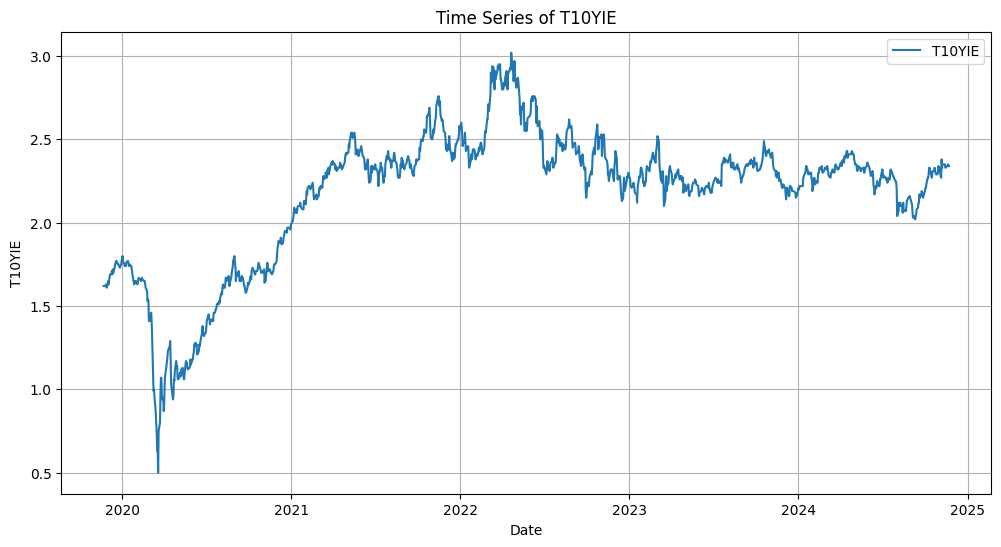

In [ ]:
# Plot the time series
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['T10YIE'], label='T10YIE')
plt.title('Time Series of T10YIE')
plt.xlabel('Date')
plt.ylabel('T10YIE')
plt.legend()
plt.grid()
plt.show()


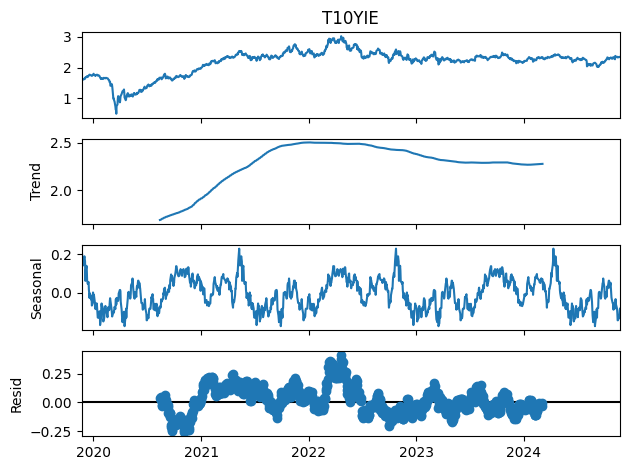

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Decompose the time series (additive model assumed here)
decomposition = seasonal_decompose(data['T10YIE'], model='additive', period=365)

# Plot the decomposed components
decomposition.plot()
plt.tight_layout()
plt.show()


Training set size: 1001
Testing set size: 251


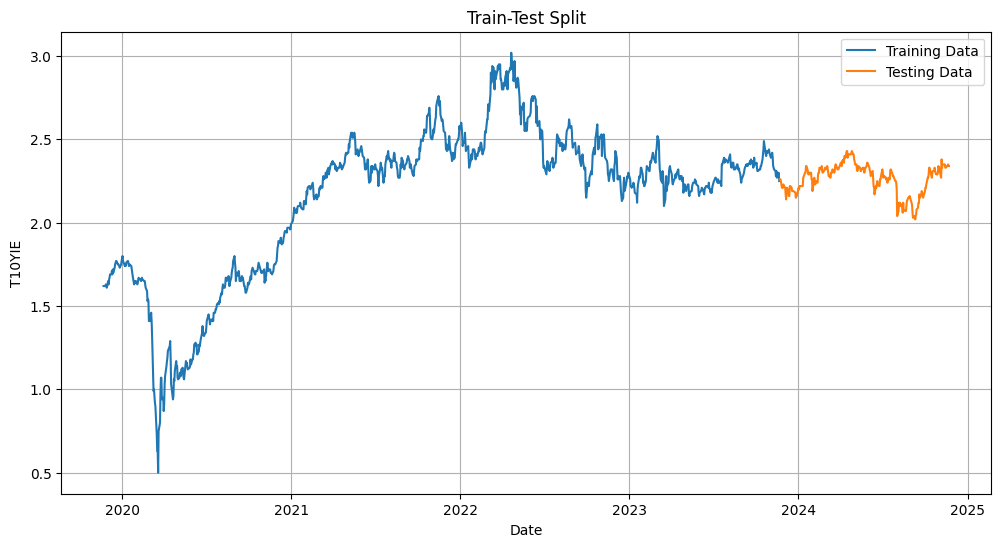

In [ ]:
# Define the train-test split ratio
train_size = int(len(data) * 0.8)

# Split the data
train = data.iloc[:train_size]
test = data.iloc[train_size:]

# Display the sizes of the train and test datasets
print(f"Training set size: {len(train)}")
print(f"Testing set size: {len(test)}")

# Plot the train and test sets
plt.figure(figsize=(12, 6))
plt.plot(train.index, train['T10YIE'], label='Training Data')
plt.plot(test.index, test['T10YIE'], label='Testing Data')
plt.title('Train-Test Split')
plt.xlabel('Date')
plt.ylabel('T10YIE')
plt.legend()
plt.grid()
plt.show()


In [ ]:
# Add lag features
for lag in range(1, 4):
    data[f'lag_{lag}'] = data['T10YIE'].shift(lag)

# Add rolling mean features
data['rolling_mean_3'] = data['T10YIE'].rolling(window=3).mean()
data['rolling_mean_7'] = data['T10YIE'].rolling(window=7).mean()

# Drop rows with NaN values due to lagging/rolling
data = data.dropna()

# Update train and test sets
train = data.iloc[:train_size]
test = data.iloc[train_size:]

# Display the new features in the training set
train.head()


,T10YIE,lag_1,lag_2,lag_3,rolling_mean_3,rolling_mean_7
DATE,,,,,,
2019-12-03,1.63,1.65,1.61,1.63,1.630000,1.625714
2019-12-04,1.66,1.63,1.65,1.61,1.646667,1.631429
2019-12-05,1.67,1.66,1.63,1.65,1.653333,1.638571
2019-12-06,1.69,1.67,1.66,1.63,1.673333,1.648571
2019-12-09,1.69,1.69,1.67,1.66,1.683333,1.657143


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Define the feature columns
features = ['lag_1', 'lag_2', 'lag_3', 'rolling_mean_3', 'rolling_mean_7']

# Separate the features and target variable
X_train = train[features]
y_train = train['T10YIE']
X_test = test[features]
y_test = test['T10YIE']

# Train the Random Forest model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions
predictions = model.predict(X_test)

# Evaluate the model
rmse = np.sqrt(mean_squared_error(y_test, predictions))
print(f"Root Mean Squared Error (RMSE): {rmse}")


Root Mean Squared Error (RMSE): 0.01751650766609391


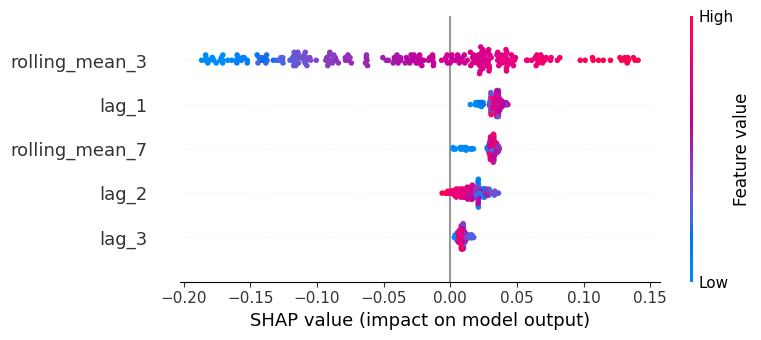

In [ ]:
import shap

# Initialize SHAP explainer
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

# Summary plot of feature importance
shap.summary_plot(shap_values, X_test)


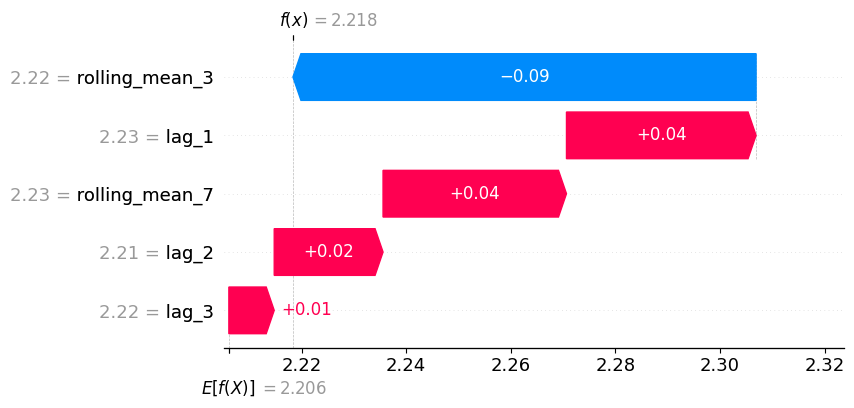

In [ ]:
# Visualize SHAP values for a single prediction
shap.plots.waterfall(shap_values[0])


In [ ]:
from sklearn.metrics import r2_score

# Calculate R-squared score
r2 = r2_score(y_test, predictions)
print(f"Model R-squared Score (Accuracy): {r2:.4f}")


Model R-squared Score (Accuracy): 0.9637
